In [17]:
!pip install pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
sns.set_style('white')

In [94]:
df = pd.read_json(r"..\..\data\raw\repos.json")[['name', 'description', 'updatedAt']]
df.shape

(100, 3)

In [95]:
# How many unique repositories do I have?
df['name'].nunique()

100

In [135]:
df['updatedAt'] = pd.to_datetime(df['updatedAt'])
df['updated_at_year'] = pd.to_datetime(df['updatedAt'], format="ISO8601").dt.year
df['updated_at_month_year'] = pd.to_datetime(df['updatedAt']).dt.strftime("%Y-%m")

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   name                   100 non-null    object             
 1   description            100 non-null    object             
 2   updatedAt              100 non-null    datetime64[ns, UTC]
 3   updated_at_year        100 non-null    int32              
 4   updated_at_month_year  100 non-null    object             
dtypes: datetime64[ns, UTC](1), int32(1), object(3)
memory usage: 3.6+ KB


In [137]:
df

,name,description,updatedAt,updated_at_year,updated_at_month_year
0,benchmark-inflation-simulator,This project aims to make a very basic demonst...,2026-09-05 06:10:00+00:00,2026,2026-09
1,journals,"Log book of my personal decision making, learn...",2026-09-02 18:59:17+00:00,2026,2026-09
2,presentations,A repository to contains all the presentations...,2026-08-29 10:54:27+00:00,2026,2026-08
3,portfolio,"Personal portfolio of Asif Sayyed, Data Scien...",2026-08-05 20:08:42+00:00,2026,2026-08
4,Theseus,Does a codebase remain the same if every line ...,2026-08-01 08:15:56+00:00,2026,2026-08
...,...,...,...,...,...
95,VBAPathologyApp,This project is a VBA application for managing...,2026-02-09 07:46:29+00:00,2026,2026-02
96,IBM-Data-Science-Ecosystem,,2026-02-09 07:46:40+00:00,2026,2026-02
97,ExtractingandVisualizingStockData,,2026-02-09 07:46:31+00:00,2026,2026-02
98,PythonProjects,This repository is contains all my python proj...,2026-02-09 07:46:32+00:00,2026,2026-02


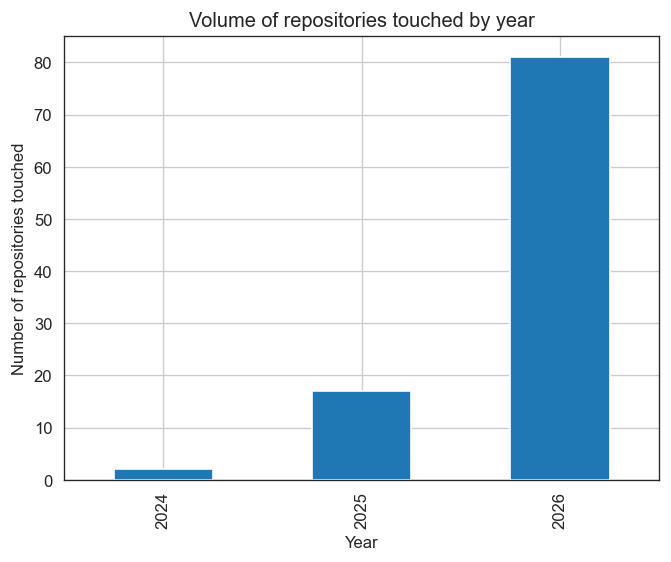

In [138]:
df.groupby('updated_at_year')['name'].count().plot(kind='bar')
plt.title("Volume of repositories touched by year")
plt.xlabel("Year")
plt.ylabel("Number of repositories touched")
plt.grid()
plt.show()

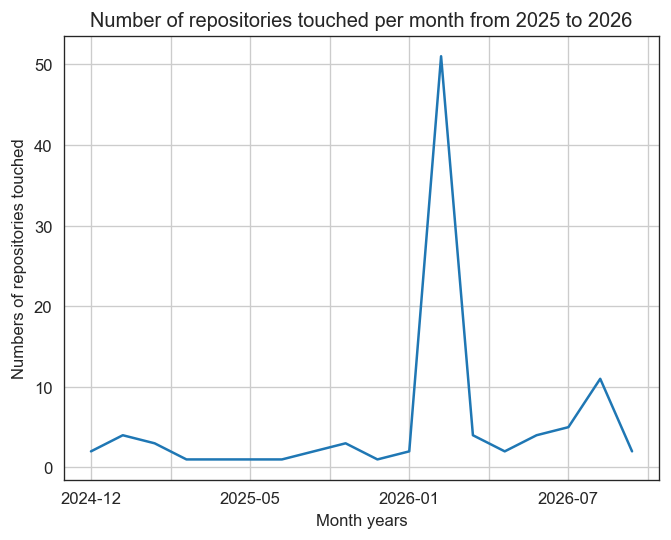

In [152]:
df.groupby('updated_at_month_year')['name'].count().plot()
plt.title("Number of repositories touched per month from 2025 to 2026")
plt.xlabel("Month years")
plt.ylabel("Numbers of repositories touched")
plt.grid()